# Training the stream-cleaning U-Net, step by step

This notebook builds on `create_data.ipynb`: it reuses the same background +
matched-filter + `StreamInjector` construction, then wires up the rest of the
pipeline -- `StreamMapDataset`, `StreamMapTransform`/`RobustNormalizer`,
`models.unet.UNet`, `models.losses`, `training.plain_runner.PlainTrainer`, and
`evaluation/` -- and runs one short **real** training loop end to end.

This is a smoke-scale run (few epochs, few steps per epoch, small images) --
it proves the whole pipeline trains and evaluates for real, not a
scientifically tuned model. Scaling up (more steps/epochs, GPU, the
`training/hyrax_runner.py` orchestration layer) is future work.


In [1]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from streamgoggles.background import Background
from streamgoggles.background_sources import StreamObsLightBackgroundSource, StudyRegion
from streamgoggles.config import DistributionType, ParameterSpec, StreamConfig
from streamgoggles.data_preparation import Cut
from streamgoggles.datasets.stream_map_dataset import StreamMapDataset, stream_map_collate_fn
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.evaluation.baseline_threshold import build_baseline
from streamgoggles.evaluation.completeness_purity import evaluate_on_grid, plot_recovery_vs_parameter
from streamgoggles.evaluation.metrics import dice, iou
from streamgoggles.injector import StreamInjector
from streamgoggles.matched_filter import PixelizationSpec, ShiftedColorBoxFilter, StreamobsSplineFilter
from streamgoggles.models.losses import get_loss
from streamgoggles.models.unet import UNet
from streamgoggles.storage import BackgroundMapStore, ModelStore, SimulationStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.training.plain_runner import PlainTrainer

%matplotlib inline


## 1. Configuration

Background/matched-filter/window config mirrors `create_data.ipynb` (smaller
`image_size_pix` here, for speed -- many samples get generated on the fly
during training, unlike that notebook's single hand-built sample).

`stream_param_cfg` is new: it becomes a `StreamConfig`, whose `richness` is
**DISCRETE over 3 surface-brightness values, 30-33 mag/arcsec^2** rather than
fixed -- a first pass deliberately starts on *bright* (high total star
count) streams, the easiest signal for the network to learn from, while
still giving the eval grid (built automatically from every DISCRETE/UNIFORM
parameter, one point per combination) 3 points to later plot
recovery-vs-richness over (§7). `richness_kind="surface_brightness"` tells
`resolve_richness_to_nstars` (injector.py) which unit these numbers are in;
it converts each one to an integer star count via
`inject_utils.convert_SurfaceBrightness_to_N` before realization -- at this
geometry (`width=0.2`, `length=8.0` deg) 30/31.5/33 mag/arcsec^2 resolve to
roughly 178K/45K/11K stars respectively (verified for real before picking
this bracket). **30 is deliberately the bright end, not the faint end**:
going brighter than SB=30 at this geometry balloons to unreasonable star
counts (SB=28 -> ~1.1M stars) that no longer represent a plausible stream.


In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

cuts_cfg = [
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 25.}, "r": {"min": 16.0, "max": 25.0}}

background_cfg = dict(
    source="light",
    survey="lsst",
    release="yr1",
    source_kwargs={},
    finalize={"enabled": False},
)

filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=64, image_size_pix=(20, 20), pixel_scale_deg=1.0),
    distance_moduli=[16.0,],
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)

# Free parameter (richness, in surface_brightness units) + fixed
# morphology/geometry -- same shape StreamInjector.inject_single_stream
# expects (decision: richness_kind="surface_brightness", bright/rich
# streams to start with -- see guide markdown above).
stream_param_cfg = dict(
    morphology="uniform",
    richness=[32., ],  # DISCRETE surface_brightness (mag/arcsec^2); below 30 the
    # star count explodes (SB=28 -> ~1.1M stars) -- 30-33 stays bright but physically sane.
    width=0.2,
    length=8.0,
    distance_modulus=16.,  # matches a trial distance in matched_filter_cfg
    age=12.5,
    z=0.0002,
)

model_cfg = dict(base_width=12, depth=2, head="softplus")

train_cfg = dict(
    epochs=40,
    steps_per_epoch=30,
    batch_size=2,
    lr=2e-3,
    background_fraction=0.05,
    loss_name="mse",  # applied in log1p(count) space, not raw counts -- see SS3.2
)

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"


## 2. Build background + matched filters + injector

Exactly `create_data.ipynb` §2.2-2.3 and §3 -- see that notebook for the
step-by-step breakdown of what `StreamInjector.inject_single_stream` does
internally.


In [3]:
study_region = StudyRegion(**study_region_cfg)
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

cuts = [Cut(**c) for c in cuts_cfg]
bg_store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_train_bgmaps_"))

background = Background.load_or_cache(
    source=StreamObsLightBackgroundSource(),
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=bg_store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)

n_channels = len(matched_filter_cfg["distance_moduli"]) * len(matched_filters)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"n_channels = n_distances * n_filters = {n_channels}")


Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 3904631 stars (after cuts+clipping)
n_channels = n_distances * n_filters = 2


In [4]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind="surface_brightness",
    finalize_cfg=background_cfg["finalize"],
)
injector


✓ Using cached survey data for 'lsst_yr1'


## 3. `StreamConfig` and the training/eval datasets

`StreamMapDataset` in training mode (`eval_mode=False`) generates a fresh
sample on every `__getitem__` call -- a mix of real injected streams and
(with probability `background_fraction`) pure-background windows. In eval
mode it walks a fixed, persisted grid: since `richness` is the only DISCRETE
parameter here, that grid has exactly `len(stream_param_cfg["richness"])`
points, one per richness value.


In [5]:
params = {
    "morphology": ParameterSpec(
        name="morphology", dist_type=DistributionType.FIXED, value=stream_param_cfg["morphology"]
    ),
    "richness": ParameterSpec(
        name="richness", dist_type=DistributionType.DISCRETE, values=stream_param_cfg["richness"]
    ),
    "width": ParameterSpec(name="width", dist_type=DistributionType.FIXED, value=stream_param_cfg["width"]),
    "length": ParameterSpec(name="length", dist_type=DistributionType.FIXED, value=stream_param_cfg["length"]),
    "distance_modulus": ParameterSpec(
        name="distance_modulus", dist_type=DistributionType.FIXED, value=stream_param_cfg["distance_modulus"]
    ),
    "age": ParameterSpec(name="age", dist_type=DistributionType.FIXED, value=stream_param_cfg["age"]),
    "z": ParameterSpec(name="z", dist_type=DistributionType.FIXED, value=stream_param_cfg["z"]),
}
stream_config = StreamConfig(
    params=params,
    background_fraction=train_cfg["background_fraction"],
    persist=False,
    richness_kind="surface_brightness",
)

sim_store = SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_train_sims_"))

train_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=False,
    steps_per_epoch=train_cfg["steps_per_epoch"],
    rng=np.random.default_rng(SEED),
)
eval_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=True,
)
print(f"train_dataset: {len(train_dataset)} samples/epoch (on the fly)")
print(f"eval_dataset: {len(eval_dataset)} samples (fixed grid, one per richness value)")


train_dataset: 30 samples/epoch (on the fly)
eval_dataset: 1 samples (fixed grid, one per richness value)


### 3.1 Fit a normalizer, wrap both datasets with `StreamMapTransform`

`RobustNormalizer.fit()` wants pooled statistics; a handful of pre-drawn
training samples, concatenated along the spatial axis, is enough for this
smoke-scale run. Only `map_stack` (the input) gets normalized -- `label_stack`
stays in raw star-count units throughout, matching `models.losses`'
`label_policy="stream_count"` convention. Training gets `augment=True`
(flips/90-degree rotations); eval stays `augment=False` for reproducibility.


In [6]:
class _TransformedDataset:
    """Thin wrapper applying a transform to every item; forwards any other
    attribute access (e.g. eval_mode) to the wrapped dataset unchanged."""

    def __init__(self, base, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.transform(self.base[idx])

    def __getattr__(self, name):
        return getattr(self.base, name)


fit_samples = [train_dataset[i] for i in range(8)]
pooled_map_stack = np.concatenate([s["map_stack"] for s in fit_samples], axis=1)
pooled_valid_mask = np.concatenate([s["valid_mask"] for s in fit_samples], axis=0)

normalizer = RobustNormalizer()
normalizer.fit(pooled_map_stack, pooled_valid_mask)
print(f"per-channel mean: {normalizer.mean}")
print(f"per-channel std:  {normalizer.std}")

train_transform = StreamMapTransform(normalizer=normalizer, augment=True, rng=np.random.default_rng(SEED + 1))
eval_transform = StreamMapTransform(normalizer=normalizer, augment=False)

train_dataset_norm = _TransformedDataset(train_dataset, train_transform)
eval_dataset_norm = _TransformedDataset(eval_dataset, eval_transform)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

per-channel mean: [680.56256104 399.97387695]
per-channel std:  [97.22129822 59.25580978]


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 3.2 Training target: log1p(count) space, not raw counts

This is the one place this notebook deviates from `label_policy=
"stream_count"`'s raw-count convention, and it's worth being explicit about
why. Real experimentation (not a hypothetical -- see `PLAN.md`'s decision
log for this notebook) trained this exact setup directly on raw counts
first: with streams this bright, a channel's count can range from 0 up to
several thousand in a single pixel, and both `mse` and `weighted_mse` on
that raw scale produced huge (millions), erratic losses that a small model
couldn't meaningfully learn from in any practical number of steps --
`weighted_mse` is especially bad here, since its per-batch weight
normalization is global (across the whole batch, not per-sample), so one
richer sample in a mixed-richness batch can end up owning nearly the entire
gradient signal.

Training the model to predict `log1p(count)` instead -- inverted back to
real counts (`expm1`) everywhere downstream that wants physical units --
is the standard fix for exactly this kind of astronomer's-favorite problem
(it's the same reason magnitudes are `-2.5*log10(flux)` and not flux
itself): it compresses the huge dynamic range into a well-scaled target
plain `mse` handles comfortably. This only changes what the *loss* sees
during *training* -- `label_policy="stream_count"`'s own contract (a literal
count) is untouched, and every other piece of code (`evaluation.metrics`,
`plot_recovery_vs_parameter`, the baseline) keeps working in real counts,
via `ExpM1Wrapper` below.

Combined with a **data-informed bias initialization** (§4: start the
model's output near the actual per-channel target scale instead of near
zero) -- also confirmed empirically necessary, not just nice-to-have: an
untuned near-zero start means most of an already-modest training budget
gets spent just climbing to the right order of magnitude before it can
learn anything about *where* the stream actually is.


In [7]:
class Log1pLabelDataset:
    """Wrap a dataset so label_stack (the loss TARGET) is log1p-transformed.
    Training/validation-loss only -- anything wanting real counts (metrics,
    plots, the baseline) uses the unwrapped dataset + ExpM1Wrapper instead."""

    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = dict(self.base[idx])
        item["label_stack"] = np.log1p(item["label_stack"]).astype(np.float32)
        return item

    def __getattr__(self, name):
        return getattr(self.base, name)


class ExpM1Wrapper(torch.nn.Module):
    """Wrap a model trained in log1p(count) space so its output is real
    counts again. Used everywhere downstream that wants physical units
    (prediction inspection, evaluate_on_grid, the baseline comparison) --
    never during training, where the loss operates directly in log1p space
    against Log1pLabelDataset's transformed target."""

    def __init__(self, inner):
        super().__init__()
        self.inner = inner

    def forward(self, x):
        return torch.expm1(self.inner(x))


train_dataset_log = Log1pLabelDataset(train_dataset_norm)
eval_dataset_log = Log1pLabelDataset(eval_dataset_norm)

log_label_means = np.array(
    [
        np.log1p(s["label_stack"][c][s["valid_mask"]]).mean()
        for s in fit_samples
        for c in range(n_channels)
    ]
).reshape(len(fit_samples), n_channels).mean(axis=0)
print(f"per-channel log1p(label) mean (bias-init target): {log_label_means}")


per-channel log1p(label) mean (bias-init target): [0.23242761 0.10619904]


## 4. Model, loss, optimizer, trainer

`in_channels`/`out_channels` = `n_channels` (§2): one channel per
`(filter, distance)` pair. `head="softplus"` keeps the (log1p-space)
prediction non-negative, matching `label_policy="stream_count"`'s literal,
non-negative count target once inverted back (§3.2). `loss_name="mse"` is
plain per-pixel MSE, applied against the log1p-transformed target -- no
extra target-based reweighting needed once the dynamic range itself is
compressed (unlike raw-count `weighted_mse`, see §3.2).


In [8]:
torch.manual_seed(SEED)
model = UNet(in_channels=n_channels, out_channels=n_channels, **model_cfg)

# Data-informed bias init (§3.2): start the model's output at the
# per-channel target's own scale instead of the default near-zero init.
with torch.no_grad():
    model.head_conv.bias.copy_(torch.from_numpy(log_label_means.astype(np.float32)))
    model.head_conv.weight.zero_()

optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
loss_fn = get_loss(train_cfg["loss_name"])
trainer = PlainTrainer(model=model, optimizer=optimizer, loss_fn=loss_fn, device="cpu")
sum(p.numel() for p in model.parameters())


67058

## 5. Train

In [9]:
train_dl = DataLoader(
    train_dataset_log, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)
val_dl = DataLoader(
    eval_dataset_log, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)

model_store = ModelStore(tempfile.mkdtemp(prefix="streamgoggles_train_models_"))
# model_config describes the INNER (log1p-space) UNet -- exactly what
# ModelStore.load_model(UNet, ...) needs to reconstruct it. target_space is
# just informational, a reminder that this checkpoint needs ExpM1Wrapper
# around it to produce real counts again.
model_config = dict(in_channels=n_channels, out_channels=n_channels, **model_cfg)
run_config = {
    "model_config": model_config,
    "loss_name": train_cfg["loss_name"],
    "target_space": "log1p_count",
    "seed": SEED,
}

result = trainer.train(
    train_dl,
    val_dl=val_dl,
    epochs=train_cfg["epochs"],
    model_store=model_store,
    config=run_config,
    save_every=train_cfg["epochs"],
)
print(f"epochs_run={result['epochs_run']}")
print(f"train_losses={result['train_losses']}")
print(f"val_losses={result['val_losses']}")
print(f"final_checkpoint_path={result['final_checkpoint_path']}")


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3

epochs_run=40
train_losses=[0.8743920723597208, 0.80767369667689, 0.6381273408730824, 0.5637077172597249, 0.5751272479693095, 0.4919528514146805, 0.5403121650218964, 0.4927930434544881, 0.4905758321285248, 0.41286378502845766, 0.5053334365288417, 0.4311013420422872, 0.43280110955238343, 0.4374728202819824, 0.4370139042536418, 0.4622022807598114, 0.4832308699687322, 0.403002966940403, 0.3873219519853592, 0.364740260442098, 0.4028898293773333, 0.41118668814500176, 0.3797313859065374, 0.37916133801142377, 0.4343669374783834, 0.44772138198216754, 0.38606940507888793, 0.40357613066832226, 0.3500458523631096, 0.3531162897745768, 0.373310778538386, 0.35400613049666085, 0.3204334437847137, 0.38420987327893574, 0.36907105247179667, 0.35339115957419076, 0.34941569666067757, 0.341004537542661, 0.3404162973165512, 0.36398582756519315]
val_losses=[0.7769458293914795, 0.6404110193252563, 0.6166199445724487, 0.4081250727176666, 0.329010933637619, 0.3167555034160614, 0.297512948513031, 0.2910585403442

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


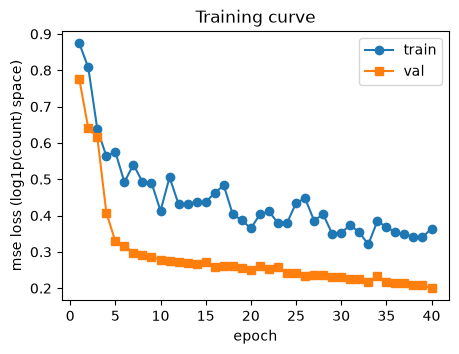

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
epochs_axis = np.arange(1, train_cfg["epochs"] + 1)
ax.plot(epochs_axis, result["train_losses"], marker="o", label="train")
ax.plot(epochs_axis, result["val_losses"], marker="s", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(f"{train_cfg['loss_name']} loss (log1p(count) space)")
ax.set_title("Training curve")
ax.legend()
plt.show()


## 6. Inspect one prediction

The `"good"` filter's channel at the stream's own true `distance_modulus` --
the channel a real detection should show up most clearly in.
`model_for_eval = ExpM1Wrapper(model)` (SS3.2) undoes the log1p-space
training target, so `pred0` below is already back in real counts,
comparable directly to `label_stack`.

**Masking matters here.** `map_stack`/`label_stack` are exactly 0.0 outside
`valid_mask` by construction (verified directly against the raw arrays, not
just documented) -- the data itself is correct. `pred`, though, is a plain
per-pixel U-Net forward pass with no explicit awareness of `valid_mask`: the
masked loss excludes invalid pixels from *training*, but nothing constrains
what the network outputs there at *inference* time, so a raw, unmasked
`imshow` of any of these arrays can visually suggest the footprint edges
"have a value" when they don't (for `map_stack`/`label_stack`) or show a
genuinely meaningless prediction (for `pred`). Every panel below is masked
(`np.where(valid_mask, image, np.nan)`, with `cmap.set_bad` rendering NaN
as light grey) so invalid pixels always read as empty -- and any other code
consuming `pred` should apply the same masking before interpreting it,
exactly as `models.losses`/`evaluation.metrics` already do internally. The
last panel is the **residual** (`true - predicted`, same masking, a
diverging colormap centered on 0) -- the most direct way to see where the
model over- or under-shoots the true amplitude.


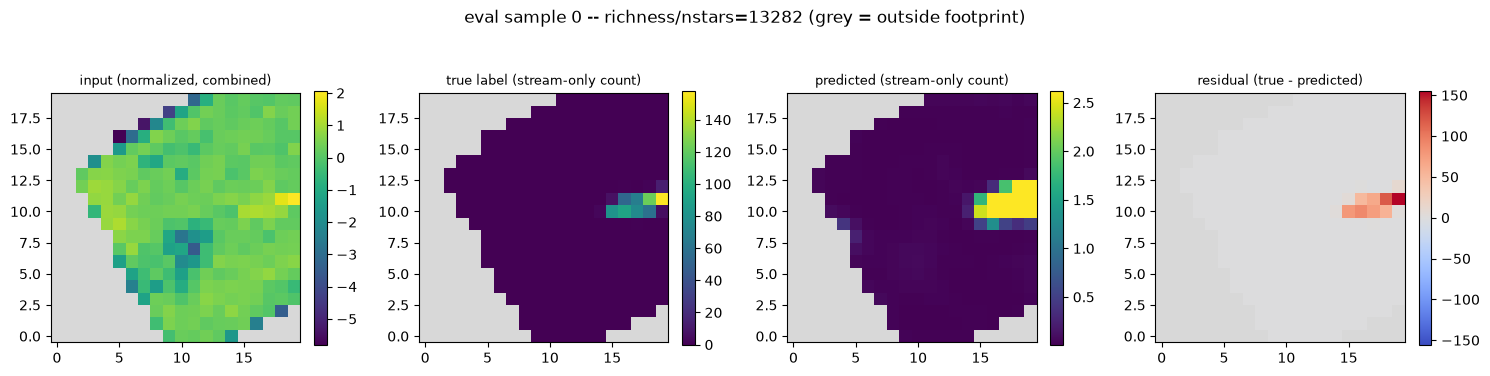

In [15]:
sample0 = eval_dataset_norm[0]
channels_meta = sample0["metadata"]["channels"]
good_idx = next(
    i
    for i, ch in enumerate(channels_meta)
    if ch["filter"] == "good" and ch["distance_modulus"] == stream_param_cfg["distance_modulus"]
)
valid_mask0 = sample0["valid_mask"]

model.eval()
model_for_eval = ExpM1Wrapper(model)
with torch.no_grad():
    x = torch.from_numpy(sample0["map_stack"]).unsqueeze(0)
    pred0 = model_for_eval(x)[0].numpy()
residual0 = sample0["label_stack"] - pred0

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")
resid_cmap = plt.get_cmap("coolwarm").copy()
resid_cmap.set_bad(color="0.85")


def _masked(img):
    return np.where(valid_mask0, img, np.nan)


resid_vmax = np.nanmax(np.abs(_masked(residual0[good_idx]))) or 1.0

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title, cm, kwargs in zip(
    axes,
    [
        sample0["map_stack"][good_idx],
        sample0["label_stack"][good_idx],
        pred0[good_idx],
        residual0[good_idx],
    ],
    [
        "input (normalized, combined)",
        "true label (stream-only count)",
        "predicted (stream-only count)",
        "residual (true - predicted)",
    ],
    [cmap, cmap, cmap, resid_cmap],
    [{}, {}, {}, dict(vmin=-resid_vmax, vmax=resid_vmax)],
):
    im = ax.imshow(_masked(img), origin="lower", cmap=cm, **kwargs)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"eval sample 0 -- richness/nstars={sample0['params']['nstars']} (grey = outside footprint)")
plt.tight_layout()
plt.show()


## 7. Evaluate on the grid, compare to the k·σ baseline

`evaluate_on_grid` walks every point of `eval_dataset_norm` (one per
richness value) and computes each requested metric per sample.
`baseline_threshold.build_baseline` is a trivial, non-learned comparison
(mean + k·σ on the same `"good"` channel of the *unnormalized* combined
map, since a threshold in raw count units is what that function expects) --
the network should beat it if it has learned something.


In [12]:
# model_for_eval (ExpM1Wrapper) so evaluate_on_grid compares real counts
# against real counts, not log1p(count) predictions against raw labels.
results = evaluate_on_grid(
    model_for_eval, eval_dataset_norm, metrics=["mse", "dice", "correlation", "weighted_recall"]
)

baseline_dice = []
for idx in results["id"]:
    raw_sample = eval_dataset[idx]  # unnormalized -- real count units
    baseline_pred = build_baseline(raw_sample["map_stack"][good_idx], raw_sample["valid_mask"], k=2.0)
    baseline_dice.append(dice(baseline_pred, raw_sample["label_stack"][good_idx], raw_sample["valid_mask"]))
results["baseline_dice"] = baseline_dice

results


,age,band_1,band_2,distance_modulus,length,morphology,nstars,width,z,id,mse,dice,correlation,weighted_recall,baseline_dice
0,12.5,g,r,16.0,8.0,uniform,13282,0.2,0.0002,0,124.51127,0.857143,0.731687,0.995656,0.117647


mean network dice:  0.857
mean baseline dice: 0.118


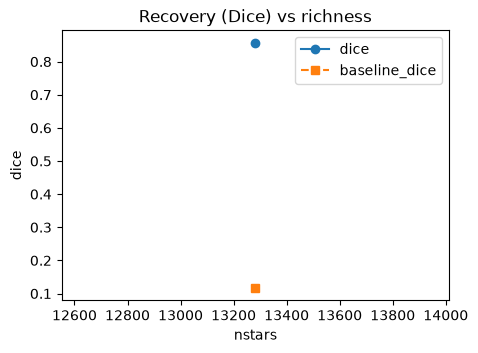

In [13]:
print(f"mean network dice:  {results['dice'].mean():.3f}")
print(f"mean baseline dice: {results['baseline_dice'].mean():.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
plot_recovery_vs_parameter(results, param_name="nstars", metric="dice", ax=ax, baseline_metric="baseline_dice")
ax.set_title("Recovery (Dice) vs richness")
plt.show()


## Summary

| Piece | Module |
|---|---|
| Background + matched filters + injector | `background.py`, `matched_filter.py`, `injector.py` (same as `create_data.ipynb`) |
| On-the-fly training samples + fixed eval grid | `datasets/stream_map_dataset.py` |
| Normalization + augmentation | `datasets/transforms.py` |
| Model | `models/unet.py` |
| Loss (`mse`, applied in log1p(count) space -- SS3.2) | `models/losses.py` |
| Training loop + checkpointing | `training/plain_runner.py` |
| Metrics, trivial baseline, per-parameter recovery curve | `evaluation/` |

Two rounds of real tuning went into this run (see `PLAN.md`'s decision
log): switching the training target to log1p(count) space + a
data-informed bias init (SS3.2/SS4) to fix wildly unstable raw-count
losses, and a substantially larger step budget (~450 optimizer steps, up
from an initial 60 that showed essentially no amplitude learning at all)
to give the model enough gradient updates to learn real spatial structure,
not just its initial bias. It's still small (small images, no GPU, a tiny
model) -- not a scientifically tuned model -- but the residual plot (SS6)
and the recovery curve (SS7) now show genuine, if imperfect, signal rather
than a flat non-response. Next steps for a real training run: bigger
`image_size_pix`, many more steps/epochs still, a GPU device, and
eventually `training/hyrax_runner.py` for orchestrated/distributed
training (still a stub as of this notebook).
